# this script calculates
- global SST anomalies
- global SST trends over a sliding window
- 


In [1]:
#from clef.code import *
import seaborn as sns

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import glob
import os
import xarray as xr
# from cmip_catalog import *
from tqdm import tqdm_notebook as tqdm
import dask.bag as dasb
from dask.diagnostics import ProgressBar
from scipy import signal
from scipy.stats import spearmanr, norm
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xskillscore as xskill

import sys
# sys.path.append('/home/548/cxc548/lib/python/bom-climate-change-variability-and-extreme-toolbox')

In [2]:
from dask.distributed import Client
client = Client(threads_per_worker = 1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41277,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39543,Total threads: 1
Dashboard: /proxy/35657/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:34571,


In [9]:
#-- Function to return an array of sliding trends starting at 'start', ending at 'end'
# with length 'length'

# def calc_trend(xarr, start,end,length):
#     #loop over years
#     for i in np.arange(start,end,1):
#         startyear=i
#         endyear=i+length
#         #extract window
#         arr = xarr.sel(year=slice(str(startyear),str(endyear)))
    
#         timedim=np.arange(0,len(arr.year))
#         arr['year'] = timedim
#         #call polyfit to calculate trend over the window. multiply by 10 so we get units of trend per decade
#         trnd = ((arr.polyfit(dim='year',deg=1,skipna=True)).polyfit_coefficients.isel(degree=0))*10
 
#         #if it's the first year, copy the trend to trnarr
#         if i == start:
#             trnarr = trnd
#         #if it's the subsequent years, concatenate the trend to trnarr
#         else:
#             trnarr = xr.concat([trnarr,trnd],dim='year')

#     trnarr['year'] = np.arange(start,end,1)

#     return trnarr

def calc_trend(xarr, start, end, length):
    """
    Compute running linear trends over windows of size `length` (years)
    from `start` to `end - 1`, returning trend per decade.

    xarr must have a coordinate "year".
    """
    
    trend_list = []

    for yr in range(start, end):
        # window
        win = xarr.sel(year=slice(str(yr), str(yr + length-1)))

        # replace year coordinate with integers 0..N-1 for polyfit
        t = np.arange(win.year.size)
        win = win.assign_coords(year=t)

        # polyfit: slope * 10 for trend per decade
        tr = (win.polyfit(dim="year", deg=1, skipna=True)
                 .polyfit_coefficients
                 .isel(degree=0) * 10)
        
        trend_list.append(tr)

    # concatenate trends along a new "year" dimension
    trnarr = xr.concat(trend_list, dim="year")

    # restore actual years
    trnarr = trnarr.assign_coords(year=np.arange(start, end))

    return trnarr

In [5]:
def detrend_1d(y, deg=1):
    """
    Removes polynomial trend from a 1D array while preserving the mean.

    Parameters:
        y (np.ndarray): Input 1D data array.
        deg (int): Degree of the polynomial to fit (default is 1 for linear detrending).

    Returns:
        np.ndarray: Detrended data with original mean retained.
    """
    x = np.arange(y.size) 
    z = np.polyfit(x, y, deg)  
    trend = np.polyval(z, x)  
    return y - trend + np.mean(y)  # Retain mean after detrending

def detrend_wrap(da, deg=1):
    """
    Applies 1D polynomial detrending across the 'time' dimension of an xarray DataArray.

    Parameters:
        da (xr.DataArray): Input data with a 'time' dimension.
        deg (int): Degree of the polynomial to fit (default is 1).

    Returns:
        xr.DataArray: Detrended data.
    """
    return xr.apply_ufunc(
        detrend_1d, da,
        input_core_dims=[['time']],  
        vectorize=True,  
        dask='parallelized',  
        kwargs={'deg': deg}  
    )

def detrend_monthly(da, deg=1):
    """
    Applies polynomial detrending separately to each calendar month across years.

    Parameters:
        da (xr.DataArray): Input data with 'time' dimension.
        deg (int): Degree of the polynomial to fit (default is 1).

    Returns:
        xr.DataArray: Monthly detrended data.
    """    
    return da.groupby('time.month').apply(
        lambda x: xr.apply_ufunc(
            detrend_1d, x,
            input_core_dims=[['time']],
            output_core_dims=[['time']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
            kwargs={'deg': deg}
        )
    )


In [6]:

def identify_enso_years_from_nino34(
    nino34: xr.DataArray,
    threshold: float = 0.5,
    runmean_months: int = 3,
    min_consecutive_months: int = 5,
    year_mode: str = "any"  # "any" or "peak"
):
    """
    Identify El Niño / La Niña events from a monthly Niño3.4 anomaly time series.

    Rules:
      - Compute a runmean_months (default 3) running mean.
      - El Niño: running mean >= +threshold for >= min_consecutive_months consecutive months.
      - La Niña: running mean <= -threshold for >= min_consecutive_months consecutive months.

    Parameters
    ----------
    nino34 : xr.DataArray
        Monthly Niño3.4 anomalies with a 'time' coordinate.
    threshold : float
        Threshold in °C (default 0.5).
    runmean_months : int
        Running mean window in months (default 3).
    min_consecutive_months : int
        Minimum consecutive months meeting threshold (default 5).
    year_mode : str
        "any"  -> return all calendar years touched by qualifying event months.
        "peak" -> return the year of the peak month for each event (max for El Niño, min for La Niña).

    Returns
    -------
    dict with:
      - "nino34_rm": running-mean series
      - "el_nino_events": list of dicts with start/end and months
      - "la_nina_events": list of dicts with start/end and months
      - "el_nino_years": sorted list of years
      - "la_nina_years": sorted list of years
    """
    if "time" not in nino34.dims:
        raise ValueError("nino34 must have a 'time' dimension.")
    if nino34.time.size < runmean_months:
        raise ValueError("Not enough data for the requested running mean window.")

    # Ensure time is sorted
    nino34 = nino34.sortby("time")

    # 3-month running mean (centered)
    rm = nino34.rolling(time=runmean_months, center=True).mean()

    def _find_runs(mask: xr.DataArray):
        """Return list of (start_idx, end_idx) inclusive runs where mask is True."""
        m = mask.fillna(False).values.astype(bool)
        if m.ndim != 1:
            raise ValueError("Expected a 1D time series.")

        runs = []
        in_run = False
        start = None
        for i, val in enumerate(m):
            if val and not in_run:
                in_run = True
                start = i
            elif (not val) and in_run:
                end = i - 1
                runs.append((start, end))
                in_run = False
        if in_run:
            runs.append((start, len(m) - 1))
        return runs

    def _events_from_runs(runs, kind: str):
        events = []
        for s, e in runs:
            length = e - s + 1
            if length < min_consecutive_months:
                continue

            months = rm.time.isel(time=slice(s, e + 1)).values
            start_time = rm.time.isel(time=s).item()
            end_time = rm.time.isel(time=e).item()

            # Peak month definition: max for El Niño, min for La Niña
            seg = rm.isel(time=slice(s, e + 1))
            if kind == "el_nino":
                peak_idx = int(seg.argmax("time"))
            else:
                peak_idx = int(seg.argmin("time"))
            peak_time = seg.time.isel(time=peak_idx).item()
            peak_value = float(seg.isel(time=peak_idx).values)

            events.append({
                "start": start_time,
                "end": end_time,
                "n_months": int(length),
                "peak_time": peak_time,
                "peak_value": peak_value,
                "months": months,
            })
        return events

    el_mask = rm >= threshold
    la_mask = rm <= -threshold

    el_runs = _find_runs(el_mask)
    la_runs = _find_runs(la_mask)

    el_events = _events_from_runs(el_runs, "el_nino")
    la_events = _events_from_runs(la_runs, "la_nina")

    def _years_from_events(events, mode: str, kind: str):
        years = set()
        if mode == "any":
            for ev in events:
                for t in ev["months"]:
                    years.add(np.datetime64(t, "M").astype(object).year)
        elif mode == "peak":
            for ev in events:
                # peak_time is a python datetime-like object after .item()
                years.add(ev["peak_time"].year)
        else:
            raise ValueError("year_mode must be 'any' or 'peak'.")
        return sorted(years)

    el_years = _years_from_events(el_events, year_mode, "el_nino")
    la_years = _years_from_events(la_events, year_mode, "la_nina")

    return {
        "nino34_rm": rm,
        "el_nino_events": el_events,
        "la_nina_events": la_events,
        "el_nino_years": el_years,
        "la_nina_years": la_years,
    }

# --- Example usage ---
# nino34_anom is a DataArray with monthly anomalies and dim 'time'
# out = identify_enso_years_from_nino34(nino34_anom, year_mode="any")
# print(out["el_nino_years"])
# print(out["la_nina_years"])
# out["el_nino_events"][0]


In [7]:
#read in SSTs
ts_obs = xr.open_dataset('/g/data/ct11/access-nri/replicas/esmvaltool/obsdata-v2/Tier2/HadISST/OBS_HadISST_reanaly_1_Amon_ts_187001-202112.nc', decode_times=True).ts


#get annual mean (for trend calculation - not detrended)
ts_obs_ann = ts_obs.groupby('time.year').mean('time')

#get detrended monthly time series (for nino 3.4 calculation)
ts_obs_dt = detrend_monthly(ts_obs, deg=1)

#get detrended monthly anomalies
ts_obs_anoms_dt = ts_obs_dt.groupby('time.month') - ts_obs_dt.sel(time=slice('1870','1920')).groupby('time.month').mean('time')
#the above is monthly data, if we wanted to do some smoothing we could maybe do 12-month running mean
ts_anoms_rolling_dt = ts_obs_anoms_dt.rolling(time=5, center=True).mean()

#now get nino3.4 index from monthly detrended anomalies
n34_obs = ts_obs_anoms_dt.sel(lat=slice(-5,5),lon=slice(190,240)).mean(['lat','lon'])


El Niño years: 61 [1877, 1878, 1888, 1889, 1896, 1897, 1899, 1900, 1902, 1903, 1904, 1905, 1906, 1911, 1912, 1913, 1914, 1915, 1918, 1919, 1923, 1924, 1925, 1926, 1930, 1931, 1940, 1941, 1942, 1951, 1957, 1958, 1963, 1964, 1965, 1966, 1968, 1969, 1972, 1973, 1976, 1977, 1982, 1983, 1986, 1987, 1988, 1991, 1992, 1994, 1995, 1997, 1998, 2002, 2003, 2009, 2010, 2015, 2016, 2018, 2019]
La Niña years: 53 [1870, 1872, 1873, 1874, 1875, 1876, 1879, 1880, 1886, 1887, 1889, 1890, 1892, 1893, 1894, 1909, 1910, 1916, 1917, 1933, 1934, 1942, 1943, 1949, 1950, 1951, 1954, 1955, 1956, 1964, 1965, 1970, 1971, 1973, 1974, 1975, 1976, 1984, 1985, 1988, 1989, 1998, 1999, 2000, 2007, 2008, 2010, 2011, 2012, 2017, 2018, 2020, 2021]


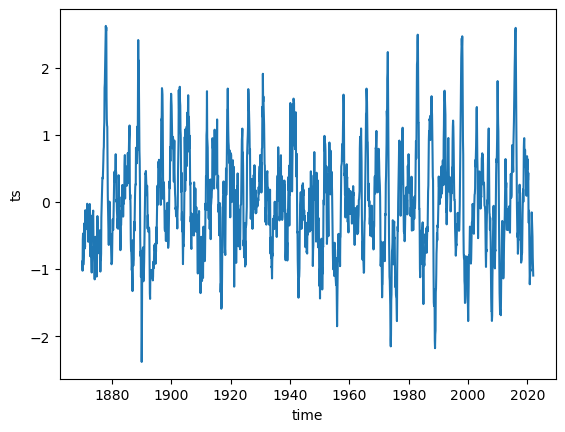

In [7]:
#plot n3.4 just to check

n34_obs.plot()
out = identify_enso_years_from_nino34(n34_obs, year_mode="any",threshold=0.6)

n_el_years = len(out["el_nino_years"])
n_la_years = len(out["la_nina_years"])

"""
  out is a dict with:
      - "nino34_rm": running-mean series
      - "el_nino_events": list of dicts with start/end and months
      - "la_nina_events": list of dicts with start/end and months
      - "el_nino_years": sorted list of years
      - "la_nina_years": sorted list of years
      """
print("El Niño years:", n_el_years, out["el_nino_years"])
print("La Niña years:", n_la_years, out["la_nina_years"])

In [8]:

obs_m20c_trnarr = calc_trend(ts_obs_ann,1850,1983,31)

# import matplotlib.animation as animation
# from IPython.display import HTML
# import cartopy.feature as cfeature

# fig, axes = plt.subplots(1,1,figsize=(20,15),
#                          subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))
cmap = plt.get_cmap('RdBu_r')
# m, M = -0.2, 0.2



<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.Data

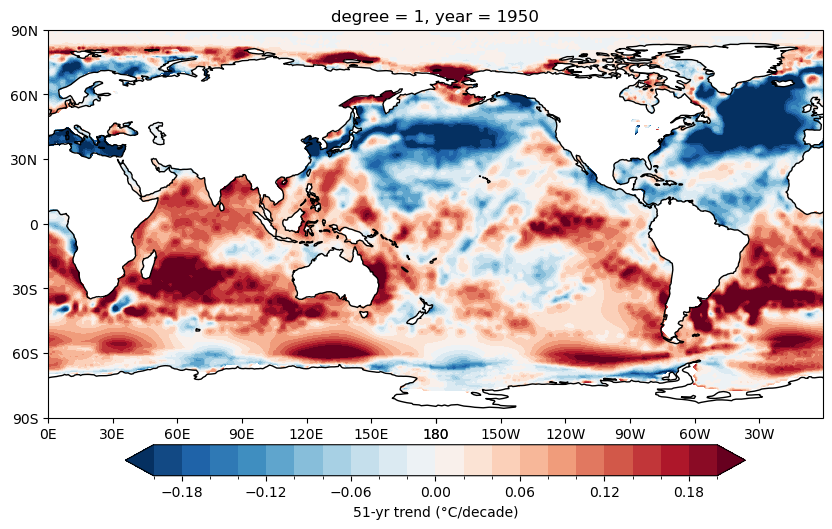

In [9]:


# Create figure and axes with projection
fig, axes = plt.subplots(
    figsize=(10, 7),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)
cmap = plt.get_cmap('RdBu_r')
m, M = -0.2, 0.2

# Plot one slice just to see
maptrn = obs_m20c_trnarr.isel(year=100).plot.contourf(
    ax=axes,
    cmap=cmap,
    vmin=m,
    vmax=M,
    levels=np.linspace(m, M, 21),
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)

# Axis formatting
axes.set_xticks(np.arange(-180, 181, 30), crs=ccrs.PlateCarree())
axes.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(zero_direction_label=True, degree_symbol='')
lat_formatter = LatitudeFormatter(degree_symbol='')
axes.xaxis.set_major_formatter(lon_formatter)
axes.yaxis.set_major_formatter(lat_formatter)

axes.coastlines(resolution='110m')
axes.set_xlabel("")
axes.set_ylabel("")

# Add colorbar
cbar = fig.colorbar(maptrn, ax=axes, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('51-yr trend (°C/decade)')

plt.show()


In [10]:
# #calculate a 34 year trend and animate

# obs_m20c_trnarr = calc_trend(ts_obs_ann,1850,1985,34)

# import matplotlib.animation as animation
# from IPython.display import HTML

# fig, axes = plt.subplots(1,1,figsize=(20,15),
#                          subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))
# cmap = plt.get_cmap('RdBu_r')
# m, M = -0.2, 0.2

# def animate(frame):
#     axes.clear()
#     obs_m20c_trnarr.isel(year=frame).plot.contourf(
#         ax=axes, cmap=cmap, vmin=m, vmax=M, 
#         levels=np.linspace(m, M, 21), 
#         add_colorbar=False, transform=ccrs.PlateCarree()
#     )
#     axes.set_title(f"34-yr trend starting {int(obs_m20c_trnarr.year[frame].values)}")
#     axes.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="black")   # country borders
#     axes.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

# ani = animation.FuncAnimation(
#     fig, animate, frames=len(obs_m20c_trnarr.year),
#     interval=200, blit=False
# )

# ani.save('animation_34yrs.gif', writer='imagemagick', fps=2)
# HTML(ani.to_jshtml())



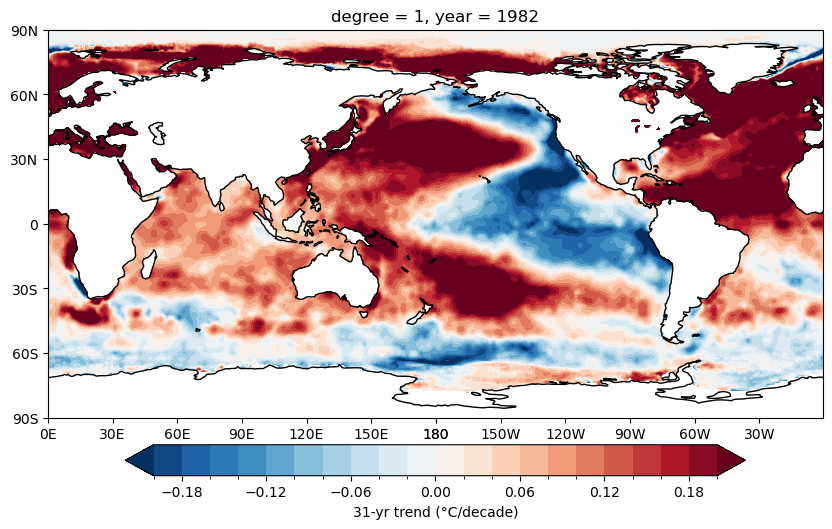

In [11]:
#plot one slice just to see


# Create figure and axes with projection
fig, axes = plt.subplots(
    figsize=(10, 7),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)

# Plot one slice just to see
maptrn = obs_m20c_trnarr.isel(year=132).plot.contourf(
    ax=axes,
    cmap=cmap,
    vmin=m,
    vmax=M,
    levels=np.linspace(m, M, 21),
    add_colorbar=False,
    transform=ccrs.PlateCarree()
)

# Axis formatting
axes.set_xticks(np.arange(-180, 181, 30), crs=ccrs.PlateCarree())
axes.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())

lon_formatter = LongitudeFormatter(zero_direction_label=True, degree_symbol='')
lat_formatter = LatitudeFormatter(degree_symbol='')
axes.xaxis.set_major_formatter(lon_formatter)
axes.yaxis.set_major_formatter(lat_formatter)

axes.coastlines(resolution='110m')
axes.set_xlabel("")
axes.set_ylabel("")

# Add colorbar
cbar = fig.colorbar(maptrn, ax=axes, orientation='horizontal', pad=0.05, shrink=0.8)
cbar.set_label('31-yr trend (°C/decade)')

plt.show()

In [11]:
#read in ACCESS ESM1.5/CANESM5/CESM2/MIROC6/NORESM2

import glob

base = "/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/*/Amon/ts/gn/latest/*.nc"

#base = "/g/data/oi10/replicas/CMIP6/CMIP/CCCma/CanESM5/historical/*/Amon/ts/gn/latest/*.nc"

files = sorted(glob.glob(base))

print(f"Found {len(files)} ts files")
ds = xr.open_mfdataset(
    files,
    combine="nested",
    concat_dim="member_id",
    parallel=True,
    chunks= 'auto'
)


da = ds['ts']        # extract the variable
da = da.transpose('time', 'lat', 'lon', 'member_id')

Found 40 ts files


In [12]:
da

<xarray.DataArray 'ts' (time: 1980, lat: 145, lon: 192, member_id: 40)> Size: 9GB
dask.array<transpose, shape=(1980, 145, 192, 40), dtype=float32, chunksize=(1205, 145, 192, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T12...
  * lat      (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: member_id
Attributes:
    standard_name:  surface_temperature
    long_name:      Surface Temperature
    comment:        Temperature of the lower boundary of the atmosphere
    units:          K
    cell_methods:   area: time: mean
    cell_measures:  area: areacella
    history:        2020-06-05T04:06:10Z altered by CMOR: replaced missing va...

In [13]:
da_ann = da.groupby('time.year').mean('time')

# da_ann = da_ann.chunk({"year": -1})

esm15_m20c_trnarr = calc_trend(da_ann,1850,1983,31)
esm15_m20c_trnarr_em = esm15_m20c_trnarr.mean('member_id').chunk({"year": -1})

In [14]:
# fig, axes = plt.subplots(1,1,figsize=(20,15),
#                          subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)))
# cmap = plt.get_cmap('RdBu_r')
# m, M = -0.2, 0.2

# def animate(frame):
#     axes.clear()
#     esm15_m20c_trnarr_em.isel(year=frame).plot.contourf(
#         ax=axes, cmap=cmap, vmin=m, vmax=M, 
#         levels=np.linspace(m, M, 21), 
#         add_colorbar=False, transform=ccrs.PlateCarree()
#     )
#     axes.set_title(f"31-yr trend starting {int(esm15_m20c_trnarr_em.year[frame].values)}")
#     axes.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="black")   # country borders
#     axes.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

# ani = animation.FuncAnimation(
#     fig, animate, frames=len(esm15_m20c_trnarr_em.year),
#     interval=200, blit=False
# )

# ani.save('esm15_animation_31yrs.gif', writer='imagemagick', fps=2)
# HTML(ani.to_jshtml())



In [15]:
#plot one slice just to see


# # Create figure and axes with projection
# fig, axes = plt.subplots(
#     figsize=(10, 7),
#     subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
# )
# cmap = plt.get_cmap('RdBu_r')

# m=-1
# M=1
# # Plot one slice just to see
# maptrn = esm15_m20c_trnarr_em.isel(year=132).plot.contourf(
#     ax=axes,
#     cmap=cmap,
#     vmin=m,
#     vmax=M,
#     levels=np.linspace(m, M, 21),
#     add_colorbar=False,
#     transform=ccrs.PlateCarree()
# )

# # Axis formatting
# axes.set_xticks(np.arange(-180, 181, 30), crs=ccrs.PlateCarree())
# axes.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())

# lon_formatter = LongitudeFormatter(zero_direction_label=True, degree_symbol='')
# lat_formatter = LatitudeFormatter(degree_symbol='')
# axes.xaxis.set_major_formatter(lon_formatter)
# axes.yaxis.set_major_formatter(lat_formatter)

# axes.coastlines(resolution='110m')
# axes.set_xlabel("")
# axes.set_ylabel("")

# # Add colorbar
# cbar = fig.colorbar(maptrn, ax=axes, orientation='horizontal', pad=0.05, shrink=0.8)
# cbar.set_label('ACCESS ESM1.5 EM 31-yr trend (°C/decade)')

# plt.show()

In [14]:
esm15_m20c_trnarr_em.isel(year=132)
# da.compute()
# da.rechunk() #'auto'

<xarray.DataArray 'polyfit_coefficients' (lat: 145, lon: 192)> Size: 223kB
dask.array<getitem, shape=(145, 192), dtype=float64, chunksize=(145, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
    degree   int64 8B 1
    year     int64 8B 1982

In [15]:
esm15_m20c_trnarr_em#.isel(year=132)

<xarray.DataArray 'polyfit_coefficients' (year: 133, lat: 145, lon: 192)> Size: 30MB
dask.array<rechunk-merge, shape=(133, 145, 192), dtype=float64, chunksize=(133, 145, 192), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 1979 1980 1981 1982
  * lat      (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
    degree   int64 8B 1

In [10]:
print(esm15_m20c_trnarr_em)

<xarray.DataArray 'polyfit_coefficients' (year: 133, lat: 145, lon: 192)> Size: 30MB
dask.array<rechunk-merge, shape=(133, 145, 192), dtype=float64, chunksize=(133, 145, 192), chunktype=numpy.ndarray>
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 1979 1980 1981 1982
  * lat      (lat) float64 1kB -90.0 -88.75 -87.5 -86.25 ... 87.5 88.75 90.0
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
    degree   int64 8B 1


In [16]:
# print(esm15_m20c_trnarr_em)
arr = esm15_m20c_trnarr_em.chunk({
    "year": -1,      # keep full year dimension in one chunk
    "lat": 50,       # break 145 → 50 + 50 + 45
    "lon": 64        # break 192 → 64 + 64 + 64
})

# arr.to_netcdf("/scratch/eg3/cxc548/ACCESS_ESM15_EM_31yr_trn_TS.nc")

In [ ]:
arr.to_netcdf("/scratch/iq82/fc6164/esmvaltool_output/process_data/ACCESS_ESM15_EM_31yr_trn_TS.nc")